### we are creating a project that will comapre different models(Navie byes, logistics Regression and SVM) and comapre them based on their performance and give you the best model.
#### we are using twitter sentiment analysis dataset for this project


Step 1. Importing the Important Librares

In [35]:
# importing all the required libraries
import pandas as pd              # For data handling
import numpy as np               # For numerical operations
import re                        # For text cleaning (regex)
import nltk                      # NLP toolkit
import pickle                    # To save/load models
import os                        # For creating directories

# NLTK tools
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import contractions
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Scikit-learn tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# remove warnings
import warnings
warnings.filterwarnings('ignore')

# Create folders for saving figures and models
if not os.path.exists('figures'):
    os.makedirs('figures')
if not os.path.exists('models'):
    os.makedirs('models')

print("✅ All libraries imported and folders created!")

✅ All libraries imported and folders created!


[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_d

Step 2. Loading the dataset

First 5 rows of dataset:
  sentiment                                             review
0  Positive  I am coming to the borders and I will kill you...
1  Positive  im getting on borderlands and i will kill you ...
2  Positive  im coming on borderlands and i will murder you...
3  Positive  im getting on borderlands 2 and i will murder ...
4  Positive  im getting into borderlands and i can murder y...

Sentiment Distribution:
sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


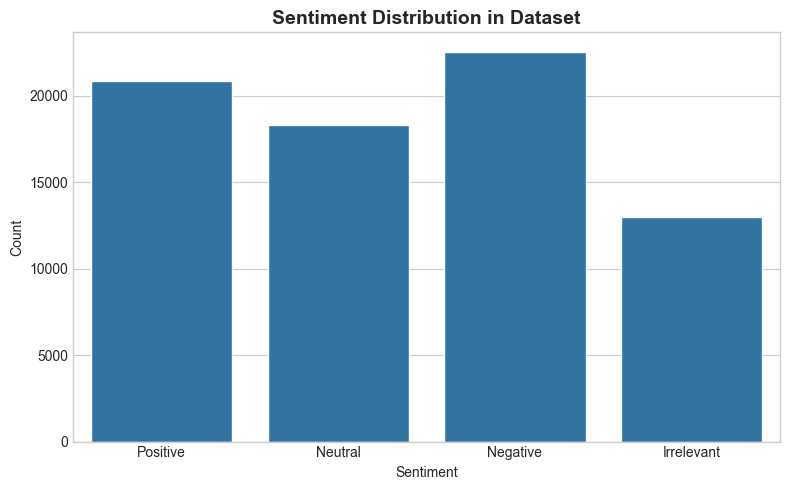

In [36]:
# Function to load and explore the dataset
def load_dataset(file_path):
    """
    Load and perform initial exploration of the dataset
    """
    # upload the dataset
    df = pd.read_csv(file_path)
    
    #check the first few rows of the dataset
    print("First 5 rows of dataset:")
    print(df.head())
    
    # check the sentiment distribution
    print("\nSentiment Distribution:")
    print(df['sentiment'].value_counts())
    
    # plot the sentiment distribution with default colors
    plt.figure(figsize=(8, 5))
    sns.countplot(x='sentiment', data=df)
    plt.title('Sentiment Distribution in Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/sentiment_distribution.png')
    plt.show()
    
    return df

# Load dataset
df = load_dataset('sentiment_dataset.csv')

Step 3: Data cleaning from missing and duplicates values

Missing Values:
sentiment      0
review       686
dtype: int64

Missing Values After Cleaning:
sentiment    0
review       0
dtype: int64

Duplicate rows found: 4229
Duplicates after removal: 0

Number of reviews after removing short reviews: 28545

First 5 rows after cleaning:
  sentiment                                             review
0  Positive  So I spent a few hours making something for fu...
1  Positive  So I spent a couple of hours doing something f...
2  Positive  So I spent a few hours doing something for fun...
3  Positive  So I spent a few hours making something for fu...
4  Positive  2010 So I spent a few hours making something f...


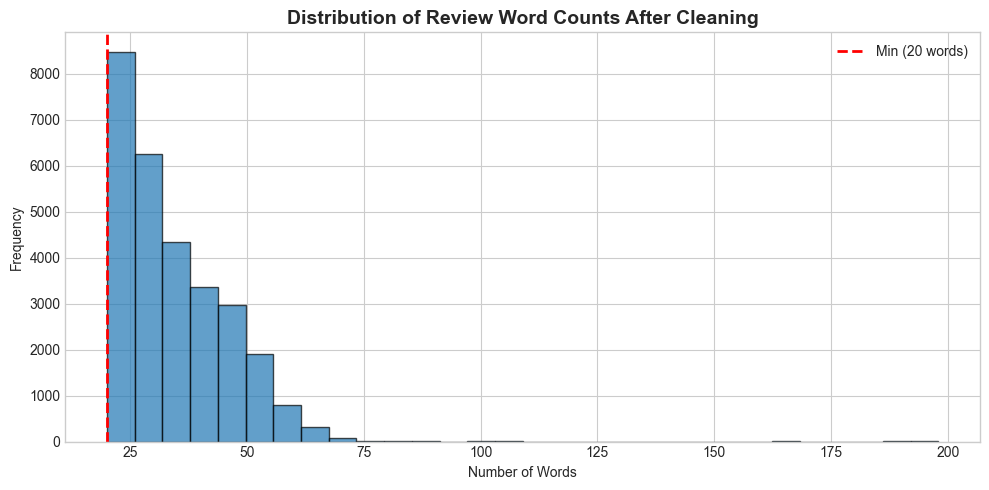

In [37]:
# peroorm data cleaning before preprocessing and training the models
def clean_dataset(df):
    """
    Clean the dataset by handling missing values, duplicates, and filtering reviews
    """
    # checking for missing values
    print("Missing Values:")
    print(df.isnull().sum())
    
    # since we got some missing values in the review column, we will drop those rows
    df.dropna(subset=['review'], inplace=True)
    
    #again check for missing values
    print("\nMissing Values After Cleaning:")
    print(df.isnull().sum())
    
    #checking for duplicates
    print(f"\nDuplicate rows found: {df.duplicated().sum()}")
    
    #we also got some duplicate rows, we will drop those as well
    df.drop_duplicates(inplace=True)
    
    #again check for duplicates
    print(f"Duplicates after removal: {df.duplicated().sum()}")
    
    ### these steps are performed beacuse the dataset is too much big and will takes time to train
    
    # creating a function that will remove short reviews (less than 20 words)
    def remove_short_reviews(text):
        """
        Remove reviews that are too short based on WORD COUNT
        """
        # Handle missing or non-string values safely
        if not isinstance(text, str):
            return np.nan
        
        # Count number of words instead of characters
        word_count = len(text.split())
        
        # Filter condition - only remove short ones, keep long ones
        if word_count < 20:
            return np.nan
        
        return text
    
    # apply the function to the review column
    df['review'] = df['review'].apply(remove_short_reviews)
    
    # drop the rows with NaN values after filtering
    df = df.dropna(subset=['review']).reset_index(drop=True)
    
    # now check the number of reviews
    print("\nNumber of reviews after removing short reviews:", len(df))
    
    #checking the head of the dataset after preprocessing
    print("\nFirst 5 rows after cleaning:")
    print(df.head())
    
    # Visualize review length distribution after cleaning
    plt.figure(figsize=(10, 5))
    plt.hist(df['review'].apply(lambda x: len(str(x).split())), bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=20, color='red', linestyle='--', linewidth=2, label='Min (20 words)')
    plt.title('Distribution of Review Word Counts After Cleaning', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figures/review_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return df

# Clean dataset (before preprocessing)
df = clean_dataset(df)


Step 4. Perform Text Preprocessing 


In [38]:
# perofm text preprocessing with all the NLP steps
def create_preprocessor():
    """
    Create and return text preprocessing function with all NLP steps
    """
    #### preprocessing
    # preprocess the text data using advance text cleaning techniques to improve the performance of the models
    # Load stopwords and lemmatizer
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    def preprocess_text(text):
        """
        Advanced NLP preprocessing pipeline:
        - Lowercasing
        - Remove URLs and HTML tags
        - Normalize currency and numbers
        - Remove special characters
        - Tokenization (NLTK)
        - POS tagging
        - Lemmatization with POS
        - Stopword removal
        - Remove short tokens
        - Clean extra spaces
        """
        
        # Handle non-string values safely
        if not isinstance(text, str):
            return ""
        
        # 1. Lowercase
        text = text.lower()
        
        # 2. Remove URLs
        text = re.sub(r'http\S+|www\S+', ' ', text)
        
        # 3. Remove HTML tags
        text = re.sub(r'<.*?>', ' ', text)
        
        # 4. Normalize currency (e.g., $100.50 → money)
        text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
        
        # 5. Normalize numbers (e.g., 123 → number)
        text = re.sub(r'\d+(\.\d+)?', ' number ', text)
        
        # 6. Remove special characters & punctuation
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        
        # 7. Tokenization using NLTK
        tokens = word_tokenize(text)
        
        # 8. POS tagging
        pos_tags = pos_tag(tokens)
        
        # 9. Helper function for POS conversion (inside function as requested)
        def get_wordnet_pos(tag):
            if tag.startswith('J'):
                return 'a'  # adjective
            elif tag.startswith('V'):
                return 'v'  # verb
            elif tag.startswith('N'):
                return 'n'  # noun
            elif tag.startswith('R'):
                return 'r'  # adverb
            else:
                return 'n'
        
        # 10. Lemmatization + stopword removal + short word filtering
        cleaned_words = []
        for word, tag in pos_tags:
            if word not in stop_words and len(word) > 2:
                pos = get_wordnet_pos(tag)
                lemma = lemmatizer.lemmatize(word, pos)
                cleaned_words.append(lemma)
        
        # 11. Join tokens
        text = ' '.join(cleaned_words)
        
        # 12. Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    return preprocess_text

# Create preprocessor and apply
preprocess_text = create_preprocessor()

# apply the preprocessing function to the reviews
print("Applying text preprocessing...")
df['review'] = df['review'].apply(preprocess_text)

# Remove any empty strings after preprocessing
df = df[df['review'] != ""]

print("Text preprocessing completed!")
print(f"Number of reviews after preprocessing: {len(df)}")
print("\nSample preprocessed text:")
print(df['review'].iloc[0][:200] + "...")

Applying text preprocessing...
Text preprocessing completed!
Number of reviews after preprocessing: 28540

Sample preprocessed text:
spend hour make something fun know huge borderland fan maya one favorite character decide make wallpaper original image versus creation make enjoy pic twitter com mlsi number number...


Step 5. Features Engineeering

In [39]:
# Prepare features using TF-IDF and labels using LabelEncoder
def prepare_features(df):
    """
    Prepare features using TF-IDF and labels using LabelEncoder
    """
    # now we will split the dataset into features and target variable
    X = df['review']  # Features (reviews)
    y = df['sentiment']  # Target variable (sentiment)
    
    # we will convert the target variable into numerical format using LabelEncoder and save the encoder for later use
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    # lets see the mapping of the labels
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print("Label Mapping:", label_mapping)
    
    # checking the shape of the features and target variable
    print("Features shape:", X.shape)
    print("Target variable shape:", y_encoded.shape)
    
    # apply TFIDF vectorization to convert text data into numerical format
    vectorizer = TfidfVectorizer(max_features=5000)  # Limit to top 5000 features
    X_tfidf = vectorizer.fit_transform(df['review']).toarray()
    
    # train test split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
    
    print(f"\nTraining set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test, vectorizer, label_encoder

# Prepare features
X_train, X_test, y_train, y_test, vectorizer, label_encoder = prepare_features(df)

Label Mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}
Features shape: (28540,)
Target variable shape: (28540,)

Training set size: (22832, 5000)
Test set size: (5708, 5000)


Step 6. Model training and evaluations

In [40]:
# Initialize, train, and evaluate all three models
def train_models():
    """
    Initialize, train, and evaluate all three models
    """
    # initilize the models - Using LinearSVC instead of SVC for faster training
    models = {
        'MultinomialNB': MultinomialNB(),
        'LinearSVC': LinearSVC(random_state=42, dual=False),
        'LogisticRegression': LogisticRegression(max_iter=200, random_state=42)
    }
    
    # train and evaluate each model
    results = {}
    
    def evaluate_model(name, model):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results[name] = {
            "model": model,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average='weighted'),
            "recall": recall_score(y_test, y_pred, average='weighted'),
            "f1": f1_score(y_test, y_pred, average='weighted'),
            "y_pred": y_pred
        }
    
    # train all models and evaluate
    for name, model in models.items():
        print(f"Training {name}...")
        evaluate_model(name, model)
    
    return models, results

# Train models
models, results = train_models()
print("\nAll models trained successfully!")

Training MultinomialNB...
Training LinearSVC...
Training LogisticRegression...

All models trained successfully!


Step 7. Result Visulaization modules


Model Comparison Table:
                    Accuracy  Precision  Recall  F1 Score
MultinomialNB         0.7129     0.7265  0.7129    0.7067
LinearSVC             0.8304     0.8301  0.8304    0.8298
LogisticRegression    0.7789     0.7787  0.7789    0.7773


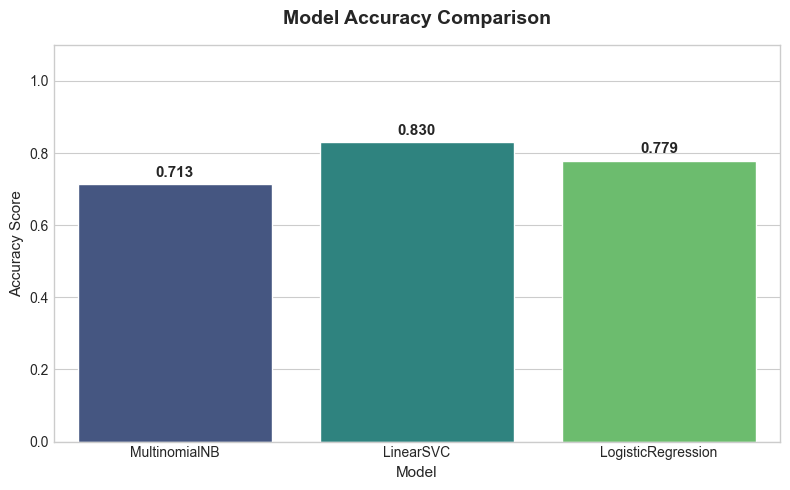

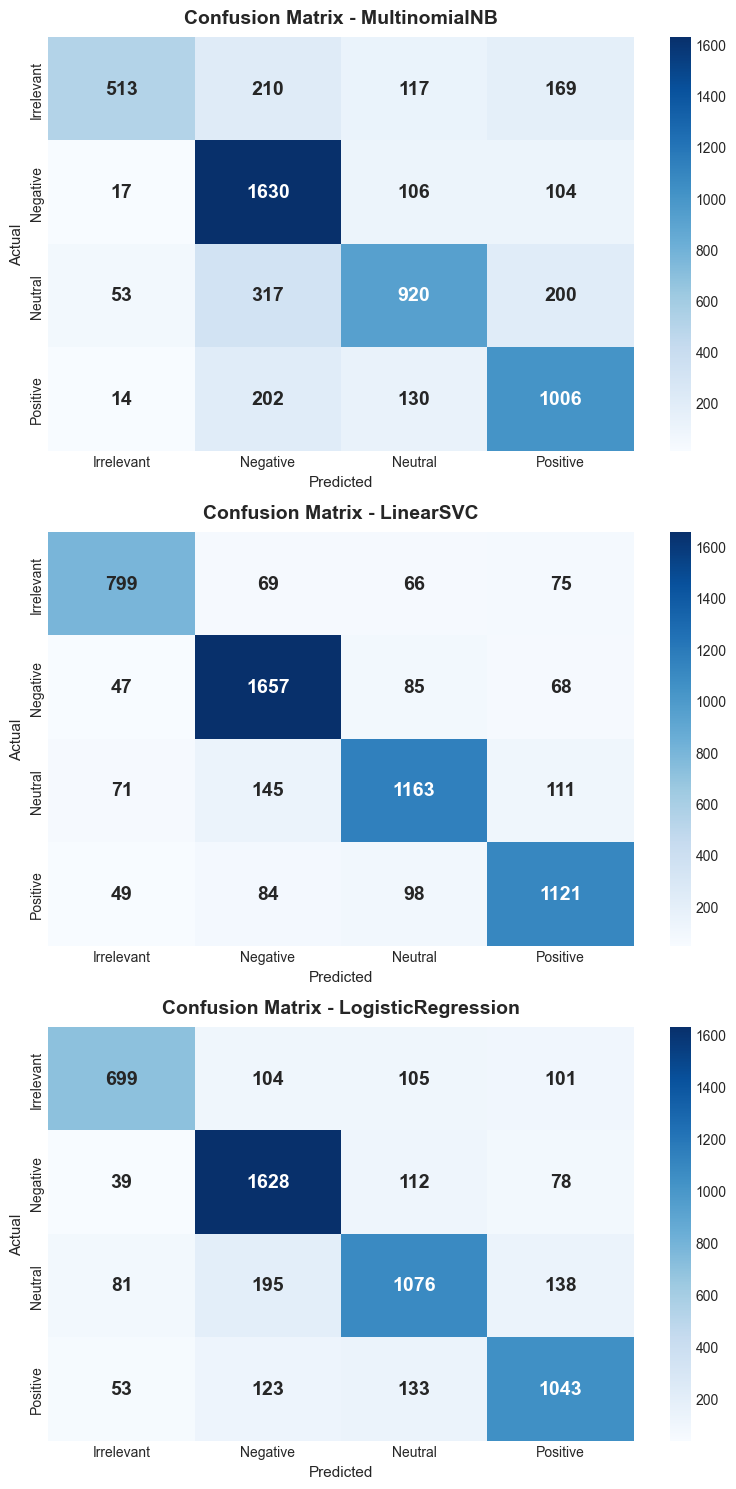

<Figure size 1000x600 with 0 Axes>

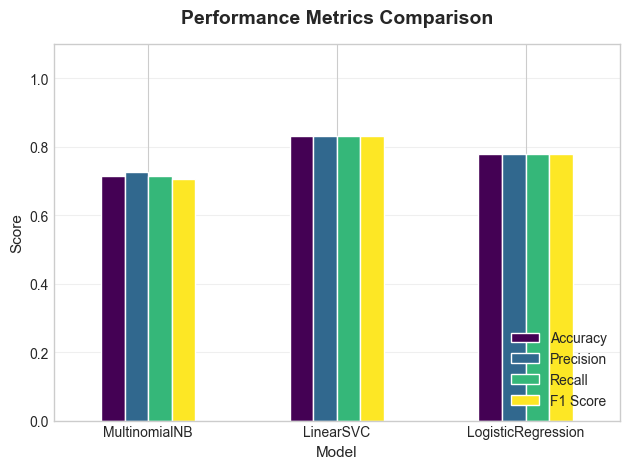

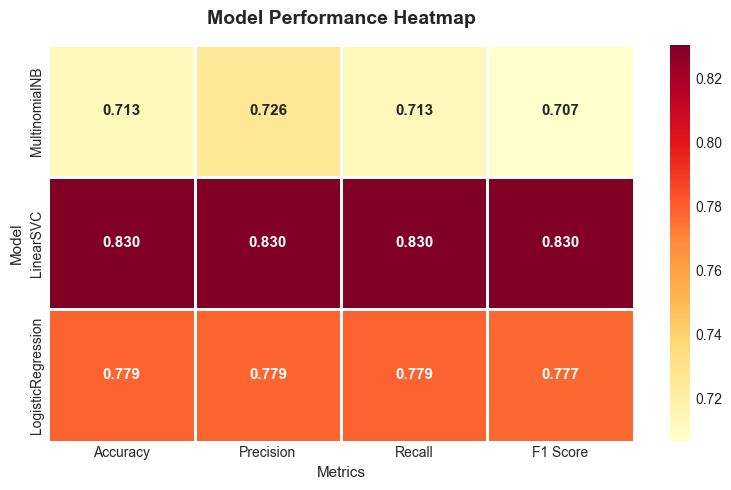

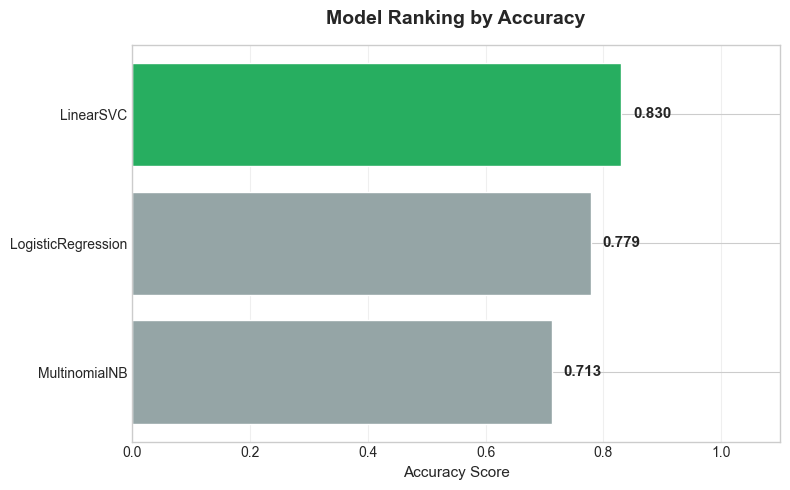


✅ All professional graphs saved to 'figures' folder!


In [41]:
# Visualize results with professional graphs and tables
def visualize_results(results, y_test, label_encoder):
    """
    Create professional visualizations for model comparison
    """
    #get the result for comparison of all the models
    results_df = pd.DataFrame({
        name: {
            "Accuracy": res["accuracy"],
            "Precision": res["precision"],
            "Recall": res["recall"],
            "F1 Score": res["f1"]
        }
        for name, res in results.items()
    }).T
    
    print("\nModel Comparison Table:")
    print("="*60)
    print(results_df.round(4))
    print("="*60)
    
    # Set style
    sns.set_style("whitegrid")
    
    # 1. Accuracy Comparison Bar Chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette='viridis')
    plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Accuracy Score', fontsize=11)
    plt.xlabel('Model', fontsize=11)
    plt.ylim(0, 1.1)
    
    # Add value labels
    for i, v in enumerate(results_df['Accuracy']):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Confusion Matrices - Column wise (stacked vertically for better readability)
    fig, axes = plt.subplots(3, 1, figsize=(8, 15))
    
    for idx, (name, res) in enumerate(results.items()):
        cm = confusion_matrix(y_test, res["y_pred"])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=label_encoder.classes_,
                    yticklabels=label_encoder.classes_,
                    annot_kws={'size': 14, 'fontweight': 'bold'})
        axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold', pad=10)
        axes[idx].set_xlabel('Predicted', fontsize=11)
        axes[idx].set_ylabel('Actual', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. All Metrics Comparison
    plt.figure(figsize=(10, 6))
    results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', colormap='viridis')
    plt.title('Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Score', fontsize=11)
    plt.xlabel('Model', fontsize=11)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Performance Heatmap
    plt.figure(figsize=(8, 5))
    sns.heatmap(results_df.astype(float), annot=True, fmt='.3f', cmap='YlOrRd', 
                linewidths=2, linecolor='white', annot_kws={'size': 11, 'fontweight': 'bold'})
    plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Model', fontsize=11)
    plt.xlabel('Metrics', fontsize=11)
    plt.tight_layout()
    plt.savefig('figures/performance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Model Ranking
    plt.figure(figsize=(8, 5))
    sorted_acc = results_df['Accuracy'].sort_values()
    colors = ['#27ae60' if x == sorted_acc.max() else '#95a5a6' for x in sorted_acc.values]
    
    ax = plt.barh(sorted_acc.index, sorted_acc.values, color=colors)
    plt.title('Model Ranking by Accuracy', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Accuracy Score', fontsize=11)
    plt.xlim(0, 1.1)
    
    # Add value labels
    for i, v in enumerate(sorted_acc.values):
        plt.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/model_ranking.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ All professional graphs saved to 'figures' folder!")
    
    return results_df

# Visualize results
results_df = visualize_results(results, y_test, label_encoder)

Step 8. Cross Validation of the models


Cross-Validation Results (5-fold):
MultinomialNB CV Score: 0.6911
LinearSVC CV Score: 0.8197
LogisticRegression CV Score: 0.7561


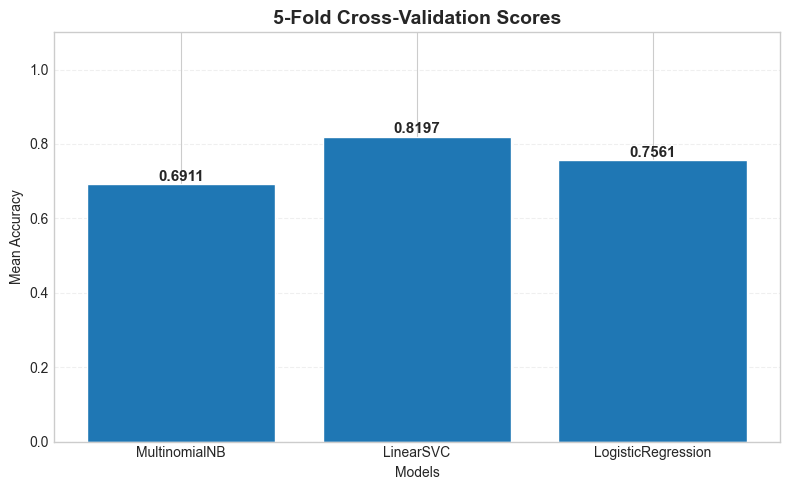

In [42]:
def perform_cross_validation(models, X_train, y_train):
    """
    Perform cross-validation for all models
    """
    # cross validation for all models
    print("\nCross-Validation Results (5-fold):")
    print("="*40)
    
    cv_results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=5)
        cv_results[name] = scores
        print(f"{name} CV Score: {scores.mean():.4f}")
    
    # Visualize cross-validation results - Simple bar chart with values on top
    plt.figure(figsize=(8, 5))
    
    cv_means = [scores.mean() for scores in cv_results.values()]
    model_names = list(cv_results.keys())
    
    bars = plt.bar(model_names, cv_means)
    
    # Add value labels on top of bars
    for bar, mean in zip(bars, cv_means):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{mean:.4f}', ha='center', fontsize=11, fontweight='bold')
    
    plt.title('5-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
    plt.ylabel('Mean Accuracy')
    plt.xlabel('Models')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('figures/cross_validation_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cv_results

# Perform cross-validation
cv_results = perform_cross_validation(models, X_train, y_train)

Step 9. Model Optimization Module

In [43]:
# model optimization with GridSearchCV for the best performing model
def optimize_best_model(results, models, X_train, y_train):
    """
    Apply GridSearchCV to the best performing model
    """
    # it will give us the best model and best model name based on accuracy
    best_model_name = max(results, key=lambda x: results[x]["accuracy"])
    best_model = results[best_model_name]["model"]
    
    print(f"Best model before tuning: {best_model_name}")
    print(f"Best accuracy before tuning: {results[best_model_name]['accuracy']:.4f}")
    
    # this will apply tuning to the selected best model and give us the best model after tuning
    if best_model_name == "LogisticRegression":
        print("Tuning Logistic Regression...")
        param_grid = {"C": [0.1, 1, 10]}
        grid = GridSearchCV(LogisticRegression(max_iter=200), param_grid, cv=3)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"Best parameters: {grid.best_params_}")
    
    elif best_model_name == "LinearSVC":
        print("Tuning LinearSVC...")
        param_grid = {"C": [0.1, 1, 10]}
        grid = GridSearchCV(LinearSVC(random_state=42, dual=False), param_grid, cv=3)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"Best parameters: {grid.best_params_}")
    
    elif best_model_name == "MultinomialNB":
        # NB usually doesn't need tuning
        print("Naive Bayes - No tuning needed")
        best_model = best_model
    
    return best_model_name, best_model

# Optimize best model
best_model_name, best_model = optimize_best_model(results, models, X_train, y_train)

Best model before tuning: LinearSVC
Best accuracy before tuning: 0.8304
Tuning LinearSVC...
Best parameters: {'C': 10}


Step 10. Saving all the models

In [44]:
# Save all trained models and preprocessing objects
def save_models(models, best_model_name, best_model, vectorizer, label_encoder):
    """
    Save all trained models and preprocessing objects
    """
    # saving the best model and the vectorizer for later use using pickle
    pickle.dump(models, open('models/all_models.pkl', 'wb'))
    pickle.dump(best_model_name, open('models/best_model_name.pkl', 'wb'))
    pickle.dump(best_model, open('models/best_model.pkl', 'wb'))
    pickle.dump(vectorizer, open('models/tfidf_vectorizer.pkl', 'wb'))
    pickle.dump(label_encoder, open('models/label_encoder.pkl', 'wb'))
    
    print("All models and preprocessing objects saved successfully!")
    print("- models/all_models.pkl")
    print("- models/best_model_name.pkl")
    print("- models/best_model.pkl")
    print("- models/tfidf_vectorizer.pkl")
    print("- models/label_encoder.pkl")

# Save models
save_models(models, best_model_name, best_model, vectorizer, label_encoder)

All models and preprocessing objects saved successfully!
- models/all_models.pkl
- models/best_model_name.pkl
- models/best_model.pkl
- models/tfidf_vectorizer.pkl
- models/label_encoder.pkl


Step 11. Predictions System.

In [45]:
# Create and test the prediction system
def create_prediction_system(results, best_model_name, preprocess_text, vectorizer, label_encoder):
    """
    Create and test the prediction system
    """
    # creating a prediction system to predict the sentiment of new reviews using the best model and the vectorizer
    def predict(original_text):
        # Keep original text for display
        processed_text = preprocess_text(original_text)
        vec = vectorizer.transform([processed_text]).toarray()
    
        predictions = {}
        print("\n" + "="*50)
        print("PREDICTION RESULTS")
        print("="*50)
        print(f"Input Text: \"{original_text}\"")
        print("-"*50)
        
        for name, res in results.items():
            pred = res["model"].predict(vec)[0]
            sentiment = label_encoder.inverse_transform([pred])[0]
            predictions[name] = sentiment
            print(f"✓ {name}: {sentiment}")
    
        print("-"*50)
        print(f"Best Model: {best_model_name}")
        print(f"Best Model Prediction: {predictions[best_model_name]}")
        print("="*50)
        
        return predictions
    
    return predict

# Create prediction function
predict = create_prediction_system(results, best_model_name, preprocess_text, vectorizer, label_encoder)

# Test the prediction system
test_texts = [
    "This product is amazing and works perfectly!",
    "Terrible experience, would not recommend to anyone.",
    "It's okay, nothing special but gets the job done."
]

for text in test_texts:
    predict(text)


PREDICTION RESULTS
Input Text: "This product is amazing and works perfectly!"
--------------------------------------------------
✓ MultinomialNB: Positive
✓ LinearSVC: Positive
✓ LogisticRegression: Positive
--------------------------------------------------
Best Model: LinearSVC
Best Model Prediction: Positive

PREDICTION RESULTS
Input Text: "Terrible experience, would not recommend to anyone."
--------------------------------------------------
✓ MultinomialNB: Negative
✓ LinearSVC: Negative
✓ LogisticRegression: Negative
--------------------------------------------------
Best Model: LinearSVC
Best Model Prediction: Negative

PREDICTION RESULTS
Input Text: "It's okay, nothing special but gets the job done."
--------------------------------------------------
✓ MultinomialNB: Negative
✓ LinearSVC: Neutral
✓ LogisticRegression: Neutral
--------------------------------------------------
Best Model: LinearSVC
Best Model Prediction: Neutral


Step 12: Final Summary Dashboard

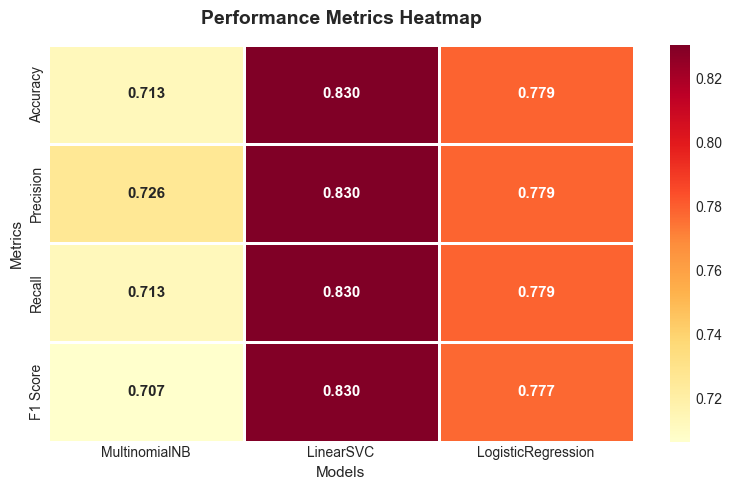

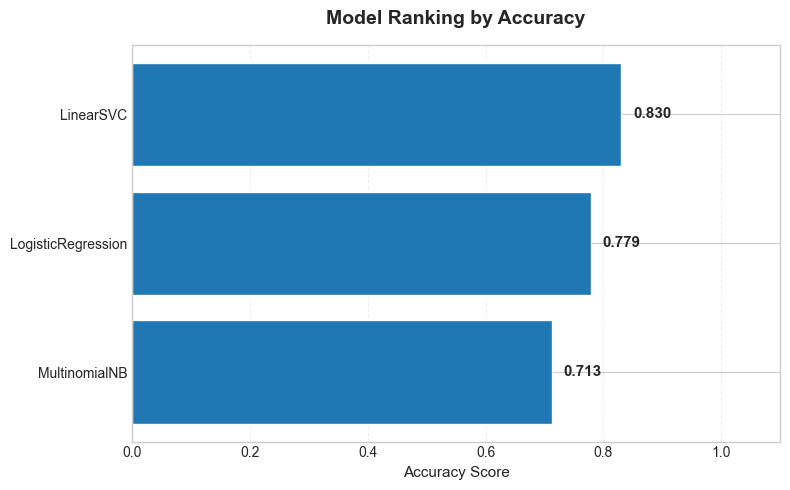


FINAL SUMMARY
Best Performing Model: LinearSVC
Best Accuracy: 0.8304
Best F1 Score: 0.8298


In [46]:
# Create final summary with simple and clean visualizations
def create_final_summary(results_df, best_model_name, cv_results):
    """
    Create final summary with simple and clean visualizations
    """
    # 1. Performance Metrics Heatmap
    plt.figure(figsize=(8, 5))
    sns.heatmap(results_df.T, annot=True, fmt='.3f', cmap='YlOrRd', 
                linewidths=1, linecolor='white',
                annot_kws={'size': 11, 'fontweight': 'bold'})
    plt.title('Performance Metrics Heatmap', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Models', fontsize=11)
    plt.ylabel('Metrics', fontsize=11)
    plt.tight_layout()
    plt.savefig('figures/final_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Model Ranking
    plt.figure(figsize=(8, 5))
    model_scores = results_df['Accuracy'].sort_values()
    
    ax = plt.barh(model_scores.index, model_scores.values)
    
    plt.title('Model Ranking by Accuracy', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Accuracy Score', fontsize=11)
    plt.xlim(0, 1.1)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels
    for i, v in enumerate(model_scores.values):
        plt.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/model_ranking_final.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)
    print(f"Best Performing Model: {best_model_name}")
    print(f"Best Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
    print(f"Best F1 Score: {results_df.loc[best_model_name, 'F1 Score']:.4f}")
    print("="*60)

# Create final summary
create_final_summary(results_df, best_model_name, cv_results)